<a href="https://colab.research.google.com/github/maqsoodahmadkhan3982-dotcom/Materials-Properties-Response/blob/main/Phase_Prediction_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Attempting to load data from: phase_region_dataset.csv

--- Training Results ---
Model Accuracy: 79.43%


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


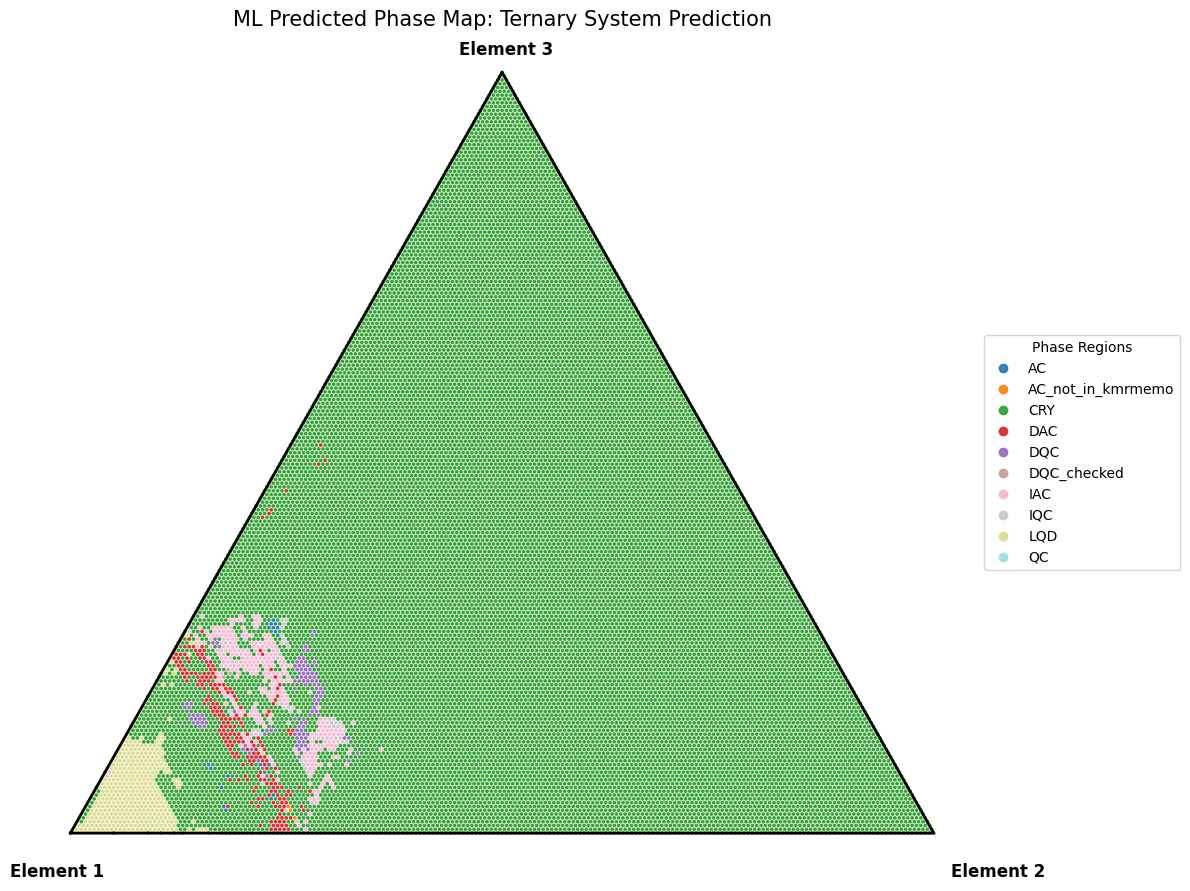


--- Prediction for custom input ---
Composition: [70. 15. 15.]
Predicted Phase Region: CRY


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [ ]:
import pandas as pd
import numpy as np
import ast
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score

def load_and_preprocess(filepath):
    """
    Loads the phase dataset and parses the Composition string into numerical features.
    """
    print(f"Attempting to load data from: {filepath}")
    df = pd.read_csv(filepath)

    # 1. Parse the 'Composition' column which is stored as a stringified dictionary
    def parse_comp(x):
        try:
            if isinstance(x, str):
                return ast.literal_eval(x)
            return x
        except Exception:
            return {}

    df['comp_dict'] = df['Composition'].apply(parse_comp)

    # 2. Extract atomic percentages for the three elements defined in the columns
    # This maps the actual chemical values to generic features (Perc1, Perc2, Perc3)
    def get_perc(row, elm_col_name):
        elm_name = row[elm_col_name]
        return row['comp_dict'].get(elm_name, 0.0)

    df['Perc1'] = df.apply(lambda r: get_perc(r, 'Element1'), axis=1)
    df['Perc2'] = df.apply(lambda r: get_perc(r, 'Element2'), axis=1)
    df['Perc3'] = df.apply(lambda r: get_perc(r, 'Element3'), axis=1)

    # 3. Encode the Target (Phase_type)
    le = LabelEncoder()
    # Ensure no missing values in target column
    df = df.dropna(subset=['Phase_type'])
    df['Phase_Label'] = le.fit_transform(df['Phase_type'].astype(str))

    return df, le

def train_phase_model(df):
    """
    Trains a Random Forest Classifier to predict the phase region.
    """
    # Features: Atomic percentages of the three components
    X = df[['Perc1', 'Perc2', 'Perc3']]
    y = df['Phase_Label']

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Random Forest is ideal for the discrete "step" boundaries found in phase diagrams
    model = RandomForestClassifier(n_estimators=200, max_depth=25, random_state=42)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    print("\n--- Training Results ---")
    print(f"Model Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")

    return model

def plot_predicted_diagram(model, le, system_name="Ternary System Prediction"):
    """
    Generates a ternary-style visualization of the predicted phase regions.
    """
    # Generate a grid of points summing to 100%
    points = []
    resolution = 0.5
    for i in np.arange(0, 100 + resolution, resolution):
        for j in np.arange(0, 100 - i + resolution, resolution):
            k = 100 - i - j
            if k >= -0.001: # Floating point safety
                points.append([i, j, k])

    grid_X = np.array(points)
    predictions = model.predict(grid_X)

    # Conversion function for Ternary -> Cartesian (Equilateral Triangle)
    def to_cartesian(p):
        a, b, c = p
        # Standard ternary plot transformation
        x = 0.5 * (2 * b + c) / 100.0
        y = (np.sqrt(3) / 2) * (c / 100.0)
        return x, y

    coords = np.array([to_cartesian(p) for p in grid_X])

    plt.figure(figsize=(12, 9))
    # Use a high-contrast colormap for distinct phase regions
    scatter = plt.scatter(coords[:, 0], coords[:, 1], c=predictions, cmap='tab20', s=3, alpha=0.9)

    # Draw triangle boundary
    plt.plot([0, 1, 0.5, 0], [0, 0, np.sqrt(3)/2, 0], color='black', lw=2)

    # Annotate corners based on the generic feature extraction
    plt.text(-0.07, -0.05, "Element 1", fontsize=12, fontweight='bold')
    plt.text(1.02, -0.05, "Element 2", fontsize=12, fontweight='bold')
    plt.text(0.45, (np.sqrt(3)/2) + 0.02, "Element 3", fontsize=12, fontweight='bold')

    plt.title(f"ML Predicted Phase Map: {system_name}", fontsize=15)
    plt.axis('off')

    # Add legend with phase names
    handles, _ = scatter.legend_elements()
    plt.legend(handles, le.classes_, title="Phase Regions", loc='center left', bbox_to_anchor=(1, 0.5))

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    # Updated to simple filename for Colab or local execution
    # If using local Windows path, you can use: r'C:\Users\...\phase_region_dataset.csv'
    csv_path = 'phase_region_dataset.csv'

    try:
        # Step 1: Data Preparation
        data, le = load_and_preprocess(csv_path)

        # Step 2: Model Training
        model = train_phase_model(data)

        # Step 3: Visualization of the global decision landscape
        plot_predicted_diagram(model, le)

        # Step 4: Random Composition Prediction
        # Enter your custom percentages here [Elem1%, Elem2%, Elem3%]
        custom_input = np.array([[70.0, 15.0, 15.0]])
        prediction_idx = model.predict(custom_input)
        result_phase = le.inverse_transform(prediction_idx)[0]

        print(f"\n--- Prediction for custom input ---")
        print(f"Composition: {custom_input[0]}")
        print(f"Predicted Phase Region: {result_phase}")

    except FileNotFoundError:
        print(f"Error: Could not find '{csv_path}'. Please upload it to your environment.")
    except Exception as e:
        print(f"An unexpected error occurred: {e}")